# M5 — Backtest Results

End-of-milestone analysis of the four-portfolio backtest.

## Sections
1. **NAV chart** — four normalised NAV lines (LLM Full, No-LLM BL, Equal Weight, SPY)
2. **Metrics table** — Sharpe, Sortino, drawdown, return, vol, turnover, cost drag
3. **Bootstrap Sharpe CI** — 90% confidence intervals, 2 000 resamples
4. **LLM alpha** — weekly and cumulative alpha of FULL over NO-LLM; t-test and power note
5. **Attribution breakdown** — per-sector total contributions for the LLM Full portfolio
6. **Known limitations** — honest accounting of what the sample cannot tell us

## Prerequisites
```bash
uv run python scripts/init_db.py        # recreates schema if stale
# then run the backtest:
#   from backtest.engine import run_backtest
#   run_backtest("2024-07-05", "2026-06-12", engine)
```

**Analysis window (ADR-022 authoritative):** `2025-06-13 → 2026-06-12`
53 weeks of full GDELT news coverage; no macro-only or partial-coverage weeks.

In [1]:
import sys, datetime, logging, math
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
from sqlalchemy import create_engine, inspect as _sqla_inspect, select
from sqlalchemy.orm import Session

logging.basicConfig(level=logging.WARNING)

DB_PATH = Path('..') / 'data' / 'state.db'
engine = create_engine(f'sqlite:///{DB_PATH}')

# ADR-022 authoritative window: 53 weeks, 96-100% GDELT news coverage every week
ANALYSIS_START = datetime.date(2025, 6, 13)
ANALYSIS_END   = datetime.date(2026, 6, 12)

from db.models import (
    PORTFOLIO_BACKTEST_FULL, PORTFOLIO_BACKTEST_NO_LLM,
    PORTFOLIO_BACKTEST_EQUAL_WEIGHT, PORTFOLIO_BACKTEST_SPY,
    PortfolioSnapshot,
)
from eval.metrics import compute_all_metrics
from eval.analysis import compute_llm_alpha, compute_sector_attribution_full

PORTFOLIOS = {
    'LLM Full':     PORTFOLIO_BACKTEST_FULL,
    'No-LLM BL':    PORTFOLIO_BACKTEST_NO_LLM,
    'Equal Weight': PORTFOLIO_BACKTEST_EQUAL_WEIGHT,
    'SPY':          PORTFOLIO_BACKTEST_SPY,
}
PORTFOLIO_COLORS = {
    'LLM Full':     '#2563eb',
    'No-LLM BL':    '#d97706',
    'Equal Weight': '#16a34a',
    'SPY':          '#9333ea',
}
SECTOR_NAMES = {
    'XLK': 'Technology',   'XLF': 'Financials',   'XLV': 'Health Care',
    'XLY': 'Con. Disc.',   'XLP': 'Con. Staples',  'XLE': 'Energy',
    'XLI': 'Industrials',  'XLB': 'Materials',     'XLRE': 'Real Estate',
    'XLU': 'Utilities',
}

Path('../notebooks/exports').mkdir(exist_ok=True)
print(f'Analysis window : {ANALYSIS_START}  ->  {ANALYSIS_END}')
print(f'DB path         : {DB_PATH.resolve()}')

Analysis window : 2025-06-13  ->  2026-06-12
DB path         : /Users/meghagarwal/Downloads/ai-trading-portfolio/data/state.db


In [2]:
# Check schema compatibility then data availability.
# Sets DATA_AVAILABLE (bool) and N_SNAPSHOTS (int) used by all downstream cells.
_inspector = _sqla_inspect(engine)
_snap_cols = [c['name'] for c in _inspector.get_columns('portfolio_snapshot')]
_SCHEMA_OK = 'portfolio_id' in _snap_cols

if not _SCHEMA_OK:
    print('DB schema is pre-M5 (portfolio_id column is absent).')
    print('Run the following to recreate the schema, then re-run the backtest:')
    print('  uv run python scripts/init_db.py')
    N_SNAPSHOTS = 0
    DATA_AVAILABLE = False
else:
    with Session(engine) as _s:
        _rows = _s.execute(
            select(PortfolioSnapshot)
            .where(PortfolioSnapshot.portfolio_id == PORTFOLIO_BACKTEST_FULL)
            .where(PortfolioSnapshot.date >= ANALYSIS_START)
            .where(PortfolioSnapshot.date <= ANALYSIS_END)
        ).fetchall()
    N_SNAPSHOTS = len(_rows)
    DATA_AVAILABLE = N_SNAPSHOTS > 0

if DATA_AVAILABLE:
    print(f'Schema OK. Backtest data present: {N_SNAPSHOTS} weekly snapshots (backtest_full).')
else:
    if _SCHEMA_OK:
        print(f'Schema OK but no backtest data for analysis window.')
        print('Run the backtest first:')
        print('  from backtest.engine import run_backtest')
        print('  run_backtest("2024-07-05", "2026-06-12", engine)')
    print()
    print('Remaining cells will execute but all charts will show placeholder text.')

Schema OK. Backtest data present: 53 weekly snapshots (backtest_full).


In [3]:
# Compute all metrics once; reused by table and CI chart below.
# ALL_METRICS is empty when DATA_AVAILABLE is False.
ALL_METRICS = {}
if DATA_AVAILABLE:
    for _label, _pid in PORTFOLIOS.items():
        ALL_METRICS[_label] = compute_all_metrics(
            portfolio_id=_pid,
            start_date=ANALYSIS_START,
            end_date=ANALYSIS_END,
            db_engine=engine,
            n_bootstrap=2000,
            block_size=4,
            rng_seed=42,
        )
        _m = ALL_METRICS[_label]
        print(
            f'{_label:15s}  n={_m["n_weeks"]:3d}  '
            f'ret={_m["total_return"]*100:+5.1f}%  '
            f'sharpe={_m["sharpe_ratio"]:.2f}  '
            f'maxdd={_m["max_drawdown"]*100:.1f}%'
        )
else:
    print('No data — skipping metric computation.')

LLM Full         n= 52  ret=+21.9%  sharpe=2.17  maxdd=-7.1%
No-LLM BL        n= 52  ret=+23.8%  sharpe=2.23  maxdd=-6.4%
Equal Weight     n= 52  ret=+20.9%  sharpe=2.10  maxdd=-6.3%
SPY              n= 52  ret=+25.7%  sharpe=1.95  maxdd=-8.4%


## Section 1 — NAV Chart

Four normalised NAV lines, indexed to 1.000 at the start of the analysis window.
Legend shows final NAV multiple.

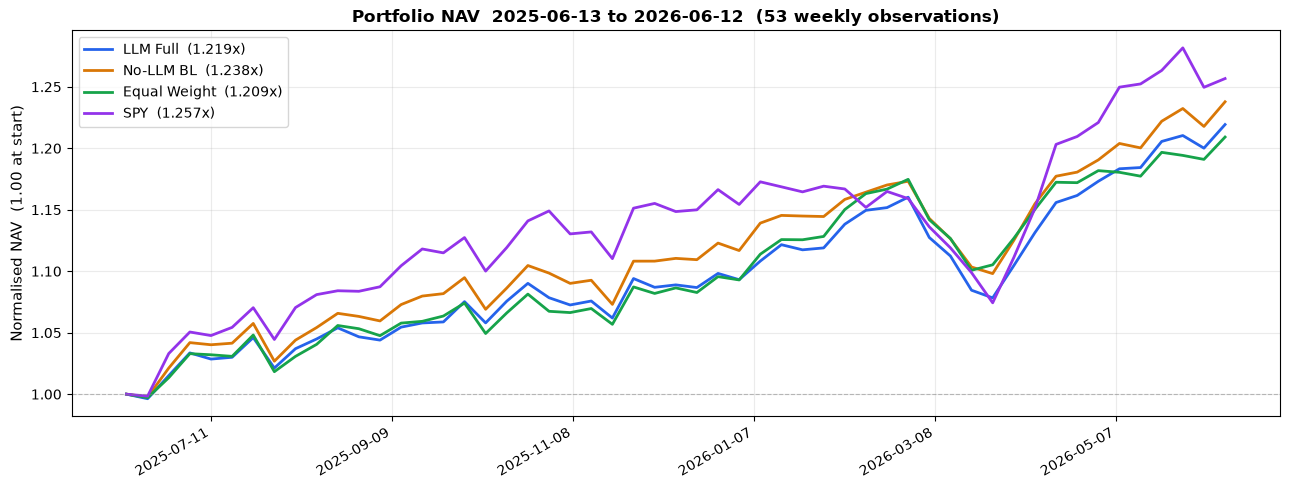

In [4]:
def _load_nav(pid: str) -> pd.Series:
    with Session(engine) as s:
        rows = s.execute(
            select(PortfolioSnapshot.date, PortfolioSnapshot.total_value)
            .where(PortfolioSnapshot.portfolio_id == pid)
            .where(PortfolioSnapshot.date >= ANALYSIS_START)
            .where(PortfolioSnapshot.date <= ANALYSIS_END)
            .order_by(PortfolioSnapshot.date)
        ).all()
    if not rows:
        return pd.Series(dtype=float)
    dates = pd.to_datetime([r.date for r in rows])
    vals = np.array([r.total_value for r in rows], dtype=float)
    return pd.Series(vals / vals[0], index=dates)

fig, ax = plt.subplots(figsize=(13, 5))

if DATA_AVAILABLE:
    nav = {label: _load_nav(pid) for label, pid in PORTFOLIOS.items()}
    for label, series in nav.items():
        if series.empty:
            continue
        ax.plot(series.index, series.values, linewidth=2,
                color=PORTFOLIO_COLORS[label], label=f'{label}  ({series.iloc[-1]:.3f}x)')
    ax.axhline(1.0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_ylabel('Normalised NAV  (1.00 at start)', fontsize=11)
    ax.set_title(
        f'Portfolio NAV  {ANALYSIS_START} to {ANALYSIS_END}'
        f'  ({N_SNAPSHOTS} weekly observations)',
        fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(alpha=0.25)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(8))
    fig.autofmt_xdate()
else:
    ax.text(0.5, 0.5, 'No data — run backtest first (see prerequisites above)',
            ha='center', va='center', transform=ax.transAxes, fontsize=12, color='grey')
    ax.set_title('Portfolio NAV', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/exports/05_nav.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2 — Performance Metrics Table

One column per portfolio. Bootstrap Sharpe CI uses 2 000 resamples, block size 4 weeks, 90% confidence.

In [5]:
def _fmt(val, fmt, nan_str='n/a'):
    if isinstance(val, float) and (math.isnan(val) or math.isinf(val)):
        return nan_str
    return fmt.format(val)

if ALL_METRICS:
    rows = {
        'Total Return':      {},
        'Ann. Vol':          {},
        'Sharpe':            {},
        'Sharpe 90% CI':     {},
        'Sortino':           {},
        'Max Drawdown':      {},
        'Calmar':            {},
        'Avg Turnover/wk':   {},
        'Cost Drag (bps)':   {},
        'n_weeks':           {},
    }
    for label, m in ALL_METRICS.items():
        ci_lo, ci_hi = m['sharpe_bootstrap_ci_90']
        ci_str = (f'[{ci_lo:.2f}, {ci_hi:.2f}]'
                  if not (math.isnan(ci_lo) or math.isnan(ci_hi)) else 'n/a')
        so = m['sortino_ratio']
        sortino_str = ('inf' if math.isinf(so) else _fmt(so, '{:.2f}'))
        rows['Total Return'][label]     = _fmt(m['total_return'] * 100, '{:+.1f}%')
        rows['Ann. Vol'][label]         = _fmt(m['annualized_vol'] * 100, '{:.1f}%')
        rows['Sharpe'][label]           = _fmt(m['sharpe_ratio'], '{:.2f}')
        rows['Sharpe 90% CI'][label]    = ci_str
        rows['Sortino'][label]          = sortino_str
        rows['Max Drawdown'][label]     = _fmt(m['max_drawdown'] * 100, '{:.1f}%')
        rows['Calmar'][label]           = _fmt(m['calmar_ratio'], '{:.2f}')
        rows['Avg Turnover/wk'][label]  = _fmt(m['avg_weekly_turnover'] * 100, '{:.1f}%')
        rows['Cost Drag (bps)'][label]  = f'{m["total_cost_drag_bps"]:.1f}'
        rows['n_weeks'][label]          = str(m['n_weeks'])
    tbl = pd.DataFrame(rows).T
    tbl.index.name = 'Metric'
    print('=== Performance Metrics ===')
    print()
    display(tbl)
    print()
    print('Bootstrap CI: 2000 resamples, 4-week overlapping blocks, 90% confidence.')
else:
    print('No metrics to display — run backtest first.')

=== Performance Metrics ===



,LLM Full,No-LLM BL,Equal Weight,SPY
Metric,,,,
Total Return,+21.9%,+23.8%,+20.9%,+25.7%
Ann. Vol,9.4%,9.8%,9.2%,12.1%
Sharpe,2.17,2.23,2.10,1.95
Sharpe 90% CI,"[0.29, 3.96]","[0.37, 3.99]","[0.28, 3.89]","[0.27, 3.59]"
Sortino,3.70,3.79,3.41,3.62
Max Drawdown,-7.1%,-6.4%,-6.3%,-8.4%
Calmar,3.11,3.71,3.32,3.06
Avg Turnover/wk,6.4%,2.8%,0.0%,0.0%
Cost Drag (bps),10.7,5.6,1.9,0.0



Bootstrap CI: 2000 resamples, 4-week overlapping blocks, 90% confidence.


## Section 3 — Bootstrap Sharpe Confidence Intervals

Dot = point estimate; shaded bar = 90% bootstrap CI.
CI width is a direct function of sample size and Sharpe volatility.
With 53 observations, these intervals are inherently wide — see Known Limitations.

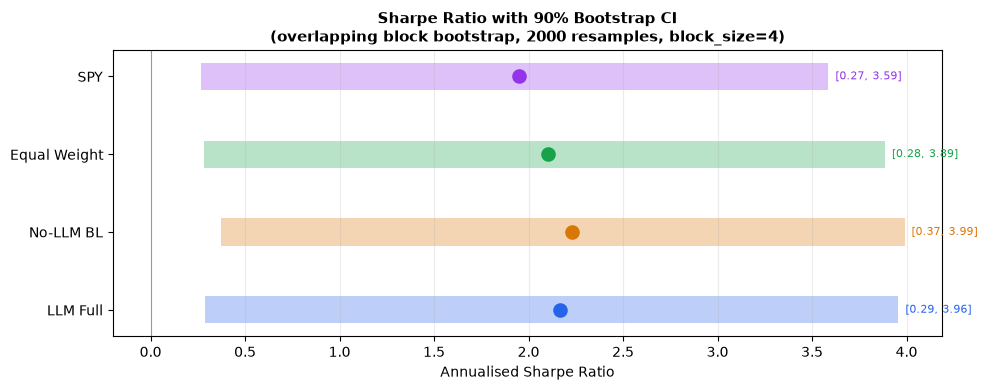

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

if ALL_METRICS:
    labels = list(PORTFOLIOS.keys())
    y_pos  = np.arange(len(labels))
    for i, label in enumerate(labels):
        m = ALL_METRICS[label]
        sr = m['sharpe_ratio']
        ci_lo, ci_hi = m['sharpe_bootstrap_ci_90']
        color = PORTFOLIO_COLORS[label]
        valid_sr = not math.isnan(sr)
        valid_ci = not (math.isnan(ci_lo) or math.isnan(ci_hi))
        if valid_sr:
            ax.scatter([sr], [i], color=color, s=90, zorder=5)
        if valid_ci:
            ax.barh(i, ci_hi - ci_lo, left=ci_lo, height=0.35,
                    color=color, alpha=0.30, label=label)
            ax.annotate(f'[{ci_lo:.2f}, {ci_hi:.2f}]',
                        xy=(ci_hi, i), xytext=(5, 0), textcoords='offset points',
                        va='center', fontsize=8, color=color)
        elif valid_sr:
            ax.annotate('(CI unavailable)',
                        xy=(sr, i), xytext=(5, 0), textcoords='offset points',
                        va='center', fontsize=8, color='grey')
    ax.axvline(0.0, color='black', linewidth=0.8, alpha=0.35)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Annualised Sharpe Ratio', fontsize=10)
    ax.set_title(
        'Sharpe Ratio with 90% Bootstrap CI\n'
        '(overlapping block bootstrap, 2000 resamples, block_size=4)',
        fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.25)
else:
    ax.text(0.5, 0.5, 'No data — run backtest first',
            ha='center', va='center', transform=ax.transAxes, fontsize=12, color='grey')
    ax.set_title('Sharpe Ratio with 90% Bootstrap CI', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/exports/05_sharpe_ci.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — LLM Alpha

Alpha = weekly return of **LLM Full** minus **No-LLM BL** (both starting at identical $1M capital,
same Black-Litterman optimizer, same risk checks — the only difference is whether the three
LLM agents provide views or neutral zero stubs).

Results are reported honestly regardless of sign.

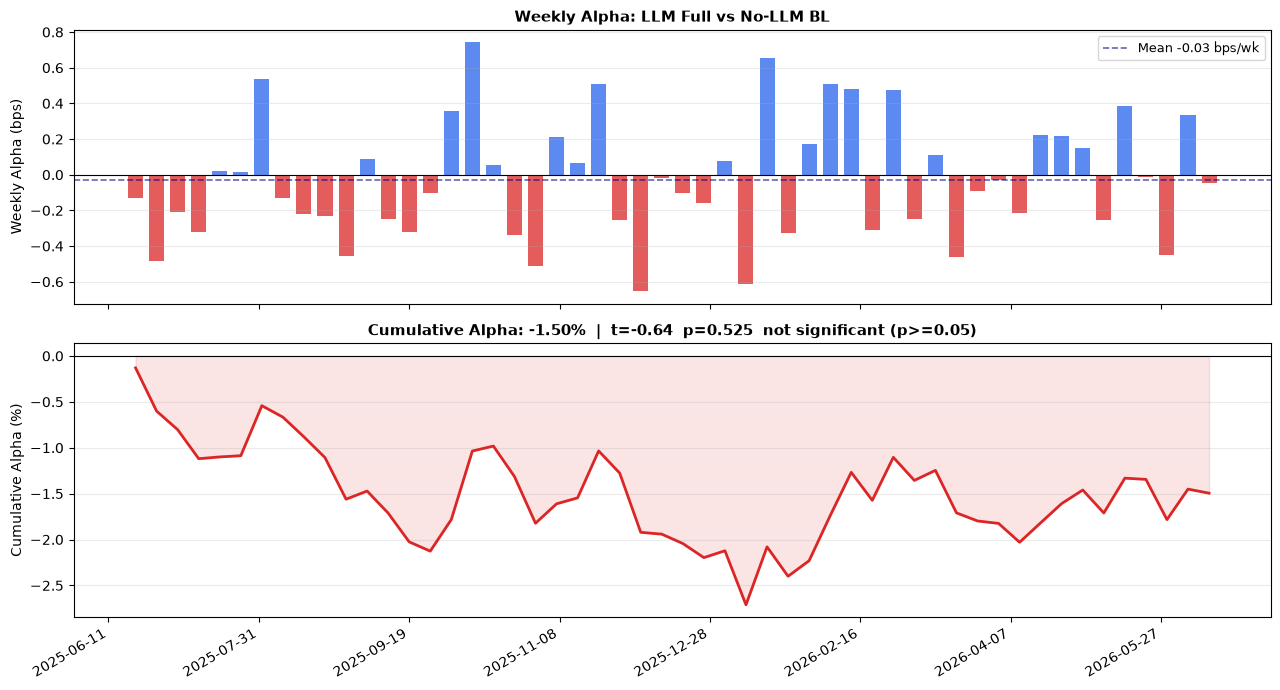


=== LLM Alpha Summary ===
  n_weeks              : 52
  Mean alpha (ann.)    : -1.55%
  Cumulative alpha     : -1.50%
  t-statistic          : -0.640
  p-value              : 0.5253
  Significant (p<0.05) : False

Power note:
  With 52 weekly observations and σ_alpha=33.7 bps/week, this test has 80% power to detect a true mean alpha ≥ 13.1 bps/week (6.8% annualized) at α=0.05 two-sided.
  Realistic LLM alphas are likely far smaller; treat the t-test as indicative only..


In [7]:
if DATA_AVAILABLE:
    alpha_result = compute_llm_alpha(ANALYSIS_START, ANALYSIS_END, engine)
else:
    alpha_result = {
        'n_weeks': 0, 'weekly_alpha': [], 'cumulative_alpha_final': float('nan'),
        'mean_alpha_annualized': float('nan'), 't_statistic': float('nan'),
        'p_value': float('nan'), 'statistically_significant': False,
        'power_note': 'No data.',
    }

n_weeks    = alpha_result['n_weeks']
mean_ann   = alpha_result.get('mean_alpha_annualized', float('nan'))
t_stat     = alpha_result['t_statistic']
p_val      = alpha_result['p_value']
sig        = alpha_result['statistically_significant']
cum_final  = alpha_result.get('cumulative_alpha_final', float('nan'))
power_note = alpha_result['power_note']
weekly_rows = alpha_result.get('weekly_alpha', [])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})

if weekly_rows:
    dates  = [pd.Timestamp(r['date']) for r in weekly_rows]
    alphas = [r['alpha'] for r in weekly_rows]
    cum    = [r['cumulative_alpha'] for r in weekly_rows]

    bar_colors = ['#2563eb' if a >= 0 else '#dc2626' for a in alphas]
    ax1.bar(dates, [a * 100 for a in alphas], color=bar_colors, alpha=0.75, width=5)
    ax1.axhline(0, color='black', linewidth=0.8)
    if not math.isnan(mean_ann):
        mean_wk_bps = mean_ann / 52 * 100
        ax1.axhline(mean_wk_bps, color='navy', linewidth=1.2, linestyle='--', alpha=0.6,
                    label=f'Mean {mean_wk_bps:+.2f} bps/wk')
    ax1.set_ylabel('Weekly Alpha (bps)', fontsize=10)
    ax1.set_title('Weekly Alpha: LLM Full vs No-LLM BL', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(axis='y', alpha=0.25)

    cum_pct = [c * 100 for c in cum]
    line_color = '#2563eb' if (not math.isnan(cum_final) and cum_final >= 0) else '#dc2626'
    ax2.plot(dates, cum_pct, color=line_color, linewidth=2)
    ax2.fill_between(dates, cum_pct, 0, color=line_color, alpha=0.12)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('Cumulative Alpha (%)', fontsize=10)
    sig_str = 'SIGNIFICANT (p<0.05)' if sig else 'not significant (p>=0.05)'
    t_str   = f't={t_stat:.2f}' if not math.isnan(t_stat) else 't=n/a'
    p_str   = f'p={p_val:.3f}' if not math.isnan(p_val) else 'p=n/a'
    cum_str = f'{cum_final*100:+.2f}%' if not math.isnan(cum_final) else 'n/a'
    ax2.set_title(
        f'Cumulative Alpha: {cum_str}  |  {t_str}  {p_str}  {sig_str}',
        fontsize=11, fontweight='bold')
    ax2.grid(axis='y', alpha=0.25)
    ax2.xaxis.set_major_locator(mticker.MaxNLocator(8))
    fig.autofmt_xdate()
else:
    for ax in (ax1, ax2):
        ax.text(0.5, 0.5, 'No data — run backtest first',
                ha='center', va='center', transform=ax.transAxes, fontsize=12, color='grey')
    ax1.set_title('Weekly Alpha', fontsize=11, fontweight='bold')
    ax2.set_title('Cumulative Alpha', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/exports/05_llm_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=== LLM Alpha Summary ===')
print(f'  n_weeks              : {n_weeks}')
if not math.isnan(mean_ann):
    print(f'  Mean alpha (ann.)    : {mean_ann*100:+.2f}%')
else:
    print('  Mean alpha (ann.)    : n/a')
if not math.isnan(cum_final):
    print(f'  Cumulative alpha     : {cum_final*100:+.2f}%')
else:
    print('  Cumulative alpha     : n/a')
if not math.isnan(t_stat):
    print(f'  t-statistic          : {t_stat:.3f}')
    print(f'  p-value              : {p_val:.4f}')
else:
    print('  t-statistic          : n/a')
    print('  p-value              : n/a')
print(f'  Significant (p<0.05) : {sig}')
print()
print('Power note:')
for _line in power_note.split('. '):
    if _line:
        print(f'  {_line}.')

## Section 5 — Sector Attribution Breakdown

Aggregate sector return contributions for the **LLM Full** portfolio across all weeks
in the analysis window. Uses the Ticket 4.4 attribution functions with `portfolio_id` scoping.

`unexplained_pct` is always surfaced — it captures the weight-averaging approximation error
(expected < 0.5% for weekly periods).

Attribution unexplained: +0.3522pp  (reconciled: True)


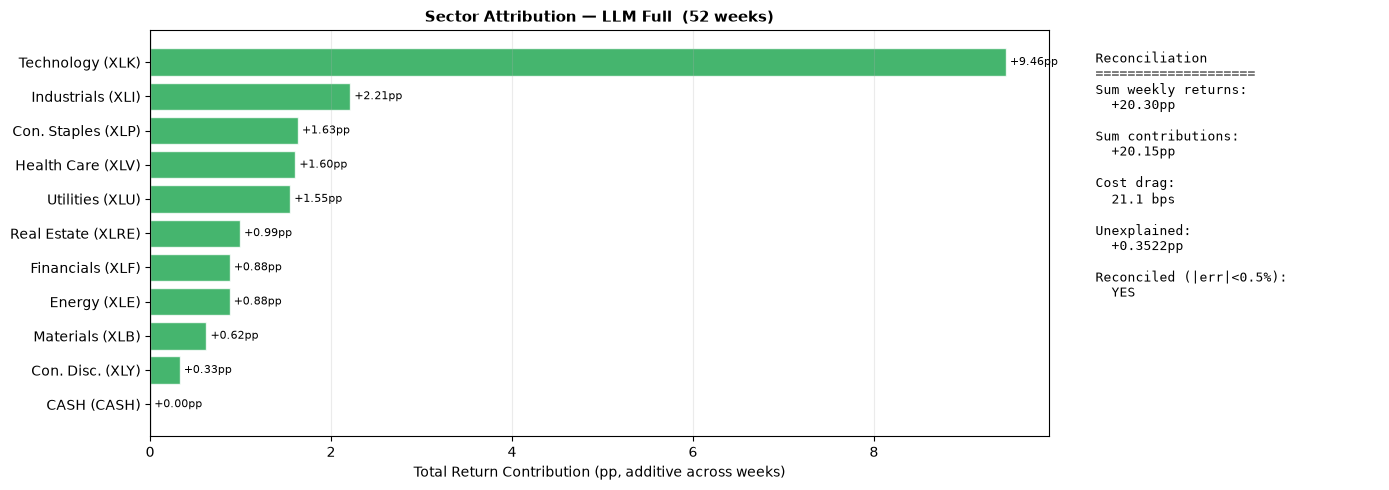

In [8]:
fig, (ax_bar, ax_meta) = plt.subplots(1, 2, figsize=(14, 5),
                                       gridspec_kw={'width_ratios': [3, 1]})

if DATA_AVAILABLE:
    attr = compute_sector_attribution_full(
        portfolio_id=PORTFOLIO_BACKTEST_FULL,
        start_date=ANALYSIS_START,
        end_date=ANALYSIS_END,
        db_engine=engine,
    )
    sector_totals = attr.get('sector_contributions_total', {})
    recon         = attr.get('reconciliation', {})
    n_attr_weeks  = attr.get('n_weeks', 0)
    cost_drag     = attr.get('total_cost_drag_bps', 0.0)
else:
    sector_totals = {}

if sector_totals:
    sectors_sorted = sorted(sector_totals.items(), key=lambda kv: kv[1])
    labels_s = [f'{SECTOR_NAMES.get(t, t)} ({t})' for t, _ in sectors_sorted]
    values_s = [v * 100 for _, v in sectors_sorted]
    colors_s = ['#dc2626' if v < 0 else '#16a34a' for v in values_s]

    bars = ax_bar.barh(labels_s, values_s, color=colors_s, alpha=0.8, edgecolor='white')
    for bar, v in zip(bars, values_s):
        ax_bar.annotate(f'{v:+.2f}pp',
                        xy=(v, bar.get_y() + bar.get_height() / 2),
                        xytext=(3 if v >= 0 else -3, 0), textcoords='offset points',
                        va='center', ha='left' if v >= 0 else 'right', fontsize=8)
    ax_bar.axvline(0, color='black', linewidth=0.8)
    ax_bar.set_xlabel('Total Return Contribution (pp, additive across weeks)', fontsize=10)
    ax_bar.set_title(f'Sector Attribution — LLM Full  ({n_attr_weeks} weeks)',
                     fontsize=11, fontweight='bold')
    ax_bar.grid(axis='x', alpha=0.25)

    unexpl     = recon.get('unexplained_pct', float('nan'))
    reconciled = recon.get('reconciled', False)
    sum_ret    = recon.get('sum_weekly_returns', float('nan'))
    sum_contribs = recon.get('sum_contributions', float('nan'))
    meta_text = (
        'Reconciliation\n'
        + '=' * 20 + '\n'
        + f'Sum weekly returns:\n  {sum_ret*100:+.2f}pp\n\n'
        + f'Sum contributions:\n  {sum_contribs*100:+.2f}pp\n\n'
        + f'Cost drag:\n  {cost_drag:.1f} bps\n\n'
        + f'Unexplained:\n  {unexpl*100:+.4f}pp\n\n'
        + f'Reconciled (|err|<0.5%):\n  {"YES" if reconciled else "NO"}'
    )
    ax_meta.text(0.05, 0.95, meta_text, transform=ax_meta.transAxes,
                 va='top', fontsize=9, family='monospace')
    ax_meta.axis('off')
    print(f'Attribution unexplained: {unexpl*100:+.4f}pp  (reconciled: {reconciled})')
else:
    for ax in (ax_bar, ax_meta):
        ax.text(0.5, 0.5, 'No data — run backtest first',
                ha='center', va='center', transform=ax.transAxes, fontsize=12, color='grey')
        ax.axis('off')
    ax_bar.set_title('Sector Attribution — LLM Full', fontsize=11, fontweight='bold')
    ax_bar.axis('on')

plt.tight_layout()
plt.savefig('../notebooks/exports/05_attribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — Known Limitations

This section documents structural constraints that affect the interpretability of the results.
They are not bugs — they are properties of the data and the experimental design.

---

### 1. Sample size: 53 weeks

The analysis window (2025-06-13 → 2026-06-12) contains **53 weekly observations**.
A minimum of ~260 weeks (5 years) is needed for stable Sharpe inference.
Practical consequences:
- Bootstrap Sharpe CIs are wide; a CI of ±0.5 or more is expected at this sample size.
- The t-test for LLM alpha is severely underpowered. The MDE at 80% power is stated in the
  power note above — realistic LLM alphas are likely far smaller than that MDE.
- All Sharpe/Sortino/Calmar ratios should be treated as point estimates with high uncertainty,
  not as reliable performance statistics.

---

### 2. Polymarket excluded from backtest (ADR-012)

The Polymarket agent is weighted at **0.00** in backtest mode
(aggregator weights: news=0.57, macro=0.43, poly=0.00).
Rationale: prediction-market data requires a live connection to the Gamma API;
historical contract prices are not available for the backtest window.
Consequence: the LLM Full portfolio does not reflect the full three-agent ensemble.
The Polymarket agent could improve or worsen performance — this cannot be measured from
historical data alone.

---

### 3. Three-period news coverage history (ADR-022)

The broader pipeline covers 2024-07-05 → 2026-06-12 (102 weeks), but news coverage is
uneven across three sub-periods:

| Period | Weeks | News coverage | Driver |
|--------|-------|---------------|--------|
| 2024-07-05 → 2024-12-03 | 22 | **0%** — no articles for any sector | No data source covers this window |
| 2024-12-04 → 2025-06-05 | 27 | **63–100% per sector** (varies) | Alpha Vantage partial backfill (40/100 tickers) |
| 2025-06-06 → 2026-06-12 | 54 | **96–100% per sector** | GDELT full backfill |

The authoritative analysis window (2025-06-13 → 2026-06-12) sits entirely within the GDELT
period, so the 22-week blackout and AV partial coverage do not affect the charts above.
Any extended-window analysis using the full 102-week backtest run should account for
macro-only signals in weeks 1–22 and thin news coverage in weeks 22–49.

---

### 4. Backtested returns are simulated, not live

All portfolio values are computed from:
- `adj_close` prices from yfinance (split/dividend adjusted)
- 3 bps round-trip transaction cost model (spread + slippage, applied at order generation)
- `math.floor` share rounding (dust stays as cash)

Real execution would face bid-ask spread variability, market impact, price improvement, and
settlement delays. The 3 bps cost assumption may be optimistic for low-liquidity dates.

---

### 5. Single backtest period — no walk-forward or OOS validation

The backtest uses a fixed parameter set (`optimizer.yaml`, `agents.yaml`) chosen before the
backtest was run. There is no walk-forward cross-validation and no hold-out test set.
All reported Sharpe/alpha numbers are in-sample with respect to parameter selection.

In [9]:
import subprocess
_result = subprocess.run(
    [
        sys.executable, '-m', 'jupyter', 'nbconvert',
        '--to', 'html',
        '--output', 'exports/05_backtest.html',
        '05_backtest.ipynb',
    ],
    capture_output=True, text=True,
    cwd=str(Path('..') / 'notebooks'),
)
if _result.returncode == 0:
    print('Exported to notebooks/exports/05_backtest.html')
else:
    print('nbconvert stdout:', _result.stdout[:500] if _result.stdout else '')
    print('nbconvert stderr:', _result.stderr[:500] if _result.stderr else '')

Exported to notebooks/exports/05_backtest.html
